<a href="https://colab.research.google.com/github/springboardmentor112r-Agri/Oil_Spill_Detection-/blob/Ritwik-Oil_Spill_Detection-/AI_Driven_System_for_Oil_Spill_Identification_and_Monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA Tasks
# 1. Load and display a few images from the dataset
# 2. Visualize the corresponding masks
# 3. Check the image and mask dimensions
# 4. Observe SAR noise patterns and pixel intensity

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/test"

image_dir = os.path.join(DATASET_PATH, "images")
mask_dir = os.path.join(DATASET_PATH, "masks")

print("Images:", len(os.listdir(image_dir)))
print("Masks :", len(os.listdir(mask_dir)))


Images: 795
Masks : 795


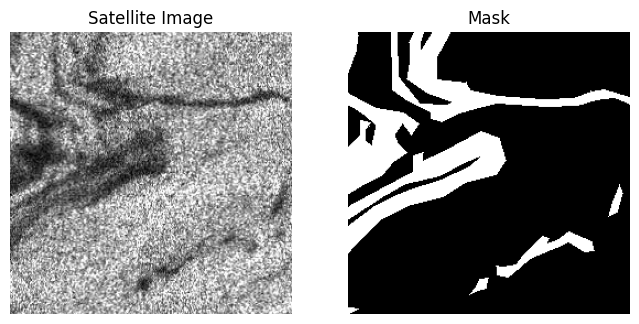

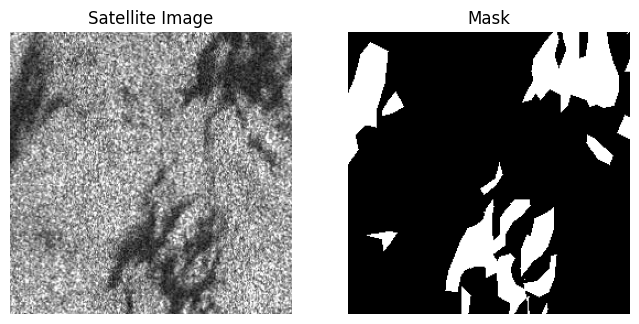

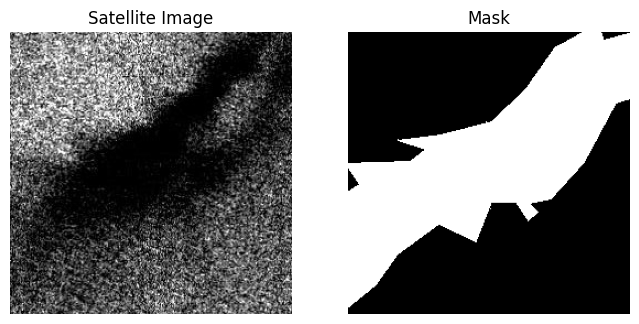

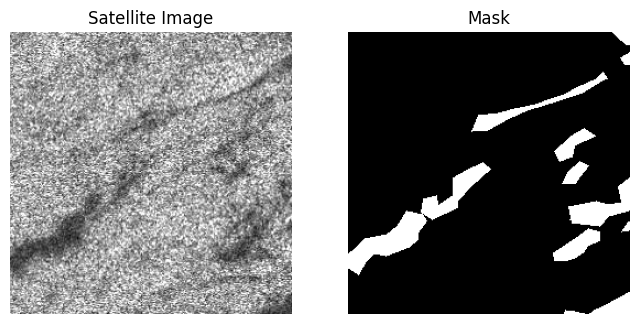

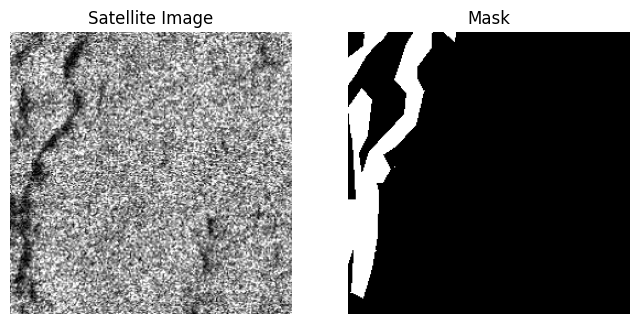

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_files = sorted(os.listdir(image_dir))[:5]
mask_files = sorted(os.listdir(mask_dir))[:5]

for i in range(5):
    img = cv2.imread(os.path.join(image_dir, image_files[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(os.path.join(mask_dir, mask_files[i]), 0)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Satellite Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask")
    plt.axis('off')

    plt.show()


In [ ]:
img = cv2.imread(os.path.join(image_dir, image_files[0]))
mask = cv2.imread(os.path.join(mask_dir, mask_files[0]), 0)

print("Image Shape:", img.shape)
print("Mask Shape :", mask.shape)


Image Shape: (256, 256, 3)
Mask Shape : (256, 256)


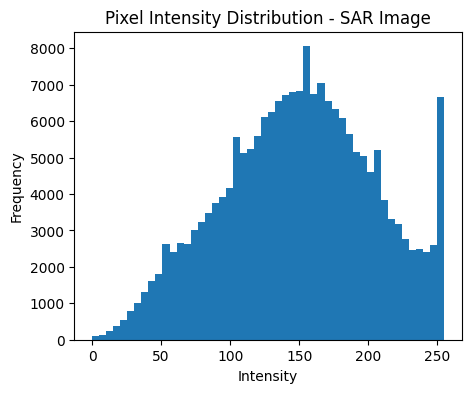

In [ ]:
plt.figure(figsize=(5,4))
plt.hist(img.ravel(), bins=50)
plt.title("Pixel Intensity Distribution - SAR Image")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()


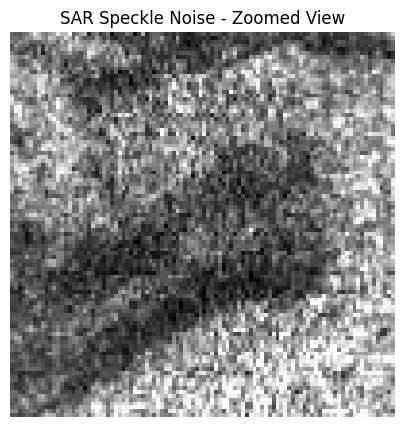

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(img[60:160, 60:160])
plt.title("SAR Speckle Noise - Zoomed View")
plt.axis('off')
plt.show()


In [ ]:
!cp -r "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring" "/content/oil_spill_dataset"


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm  # progress bar

base_dir = "/content/oil_spill_dataset"
splits = ["train", "val", "test"]

valid_exts = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")

overall_oil = 0
overall_no_oil = 0

for split in splits:
    split_dir = os.path.join(base_dir, split)
    images_dir = os.path.join(split_dir, "images")
    masks_dir  = os.path.join(split_dir, "masks")

    if not os.path.isdir(images_dir) or not os.path.isdir(masks_dir):
        print(f"\n⚠ Skipping {split}: images/ or masks/ folder not found")
        continue

    files = [f for f in os.listdir(images_dir) if f.lower().endswith(valid_exts)]
    oil_count = 0
    no_oil_count = 0

    print(f"\nProcessing {split} ({len(files)} images)...")

    for file in tqdm(files):
        mask_path = os.path.join(masks_dir, file)
        if not os.path.exists(mask_path):
            continue

        # read mask as grayscale
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue

        # faster than np.any(mask > 0)
        if cv2.countNonZero(mask) > 0:
            oil_count += 1
        else:
            no_oil_count += 1

    overall_oil += oil_count
    overall_no_oil += no_oil_count

print("\n===== OVERALL=====")
print(f"Total oil spill images   : {overall_oil}")
print(f"Total non-oil images     : {overall_no_oil}")
print(f"Grand total images       : {overall_oil + overall_no_oil}")



Processing train (4888 images)...


100%|██████████| 4888/4888 [00:03<00:00, 1427.35it/s]



Processing val (1544 images)...


100%|██████████| 1544/1544 [00:01<00:00, 1398.91it/s]



Processing test (795 images)...


100%|██████████| 795/795 [00:00<00:00, 1412.43it/s]


===== OVERALL=====
Total oil spill images   : 6936
Total non-oil images     : 291
Grand total images       : 7227
